In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# To help find your file, you can list the contents of your Google Drive.
# For example, to list the top-level contents of MyDrive, run:
# !ls '/content/drive/MyDrive/'
# If your file is in a subfolder, like 'My Drive/MyDataFolder/', you would run:
# !ls '/content/drive/MyDrive/MyDataFolder/'

# File path (updated based on `!ls` output)
# 'Traffic network' is a folder, so the CSV is likely inside it.
file_path = '/content/drive/MyDrive/Traffic network/cicids_50k_balanced.csv'

# Load CSV
try:
    df = pd.read_csv(file_path, low_memory=False)
    # Preview
    print("Shape:", df.shape)
    print(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the file name and path are correct.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (50000, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0                 80          994723                   3   
1              26184         4072400                   1   
2                 53             231                   2   
3                443         5583162                   9   
4                 80         4515742                   4   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        6                           26   
1                        6                            6   
2                        2                           86   
3                        8                          386   
4                        0                           24   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                         11607                      20   
1                 

In [ ]:
!ls '/content/drive/MyDrive/Traffic network/'

cicids_50k_balanced.csv


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# -----------------------------
# Step 1: Clean dataset
# -----------------------------

# Drop unnecessary columns (if present)
drop_cols = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle infinite and missing values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Fix column names
df.columns = df.columns.str.strip().str.replace(' ', '_')

# -----------------------------
# Step 2: Prepare labels
# -----------------------------

# Convert label to binary (BENIGN = 0, Attack = 1)
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# -----------------------------
# Step 3: Features & target
# -----------------------------

X = df.drop('Label', axis=1)
y = df['Label']

# Ensure all features are numeric
X = X.apply(pd.to_numeric, errors='coerce')
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.dropna(inplace=True)
y = y.loc[X.index]

# -----------------------------
# Step 4: Train-test split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# Step 5: Train XGBoost
# -----------------------------

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# -----------------------------
# Step 6: Evaluate
# -----------------------------

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9998994267323745

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4943
           1       1.00      1.00      1.00      5000

    accuracy                           1.00      9943
   macro avg       1.00      1.00      1.00      9943
weighted avg       1.00      1.00      1.00      9943



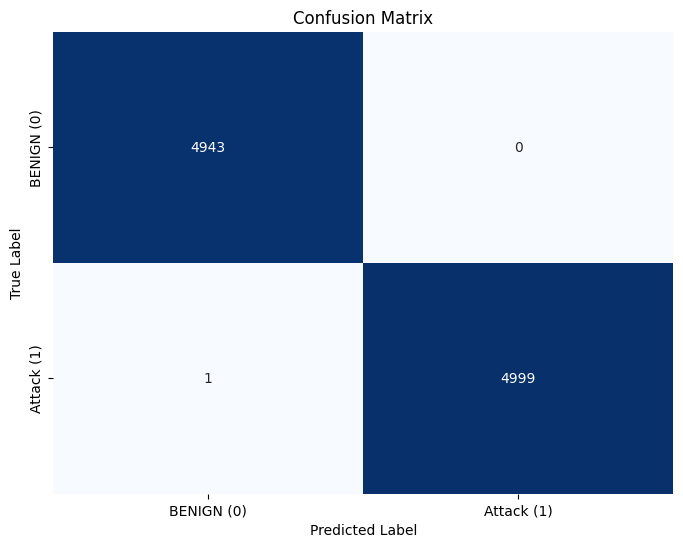

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['BENIGN (0)', 'Attack (1)'],
            yticklabels=['BENIGN (0)', 'Attack (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix shows us how many predictions were correct and incorrect.

-   **True Positives (bottom right)**: Actual Attack, Predicted Attack
-   **True Negatives (top left)**: Actual BENIGN, Predicted BENIGN
-   **False Positives (top right)**: Actual BENIGN, Predicted Attack (Type I Error)
-   **False Negatives (bottom left)**: Actual Attack, Predicted BENIGN (Type II Error)

Given the high accuracy, we expect most values to be along the diagonal (True Positives and True Negatives).

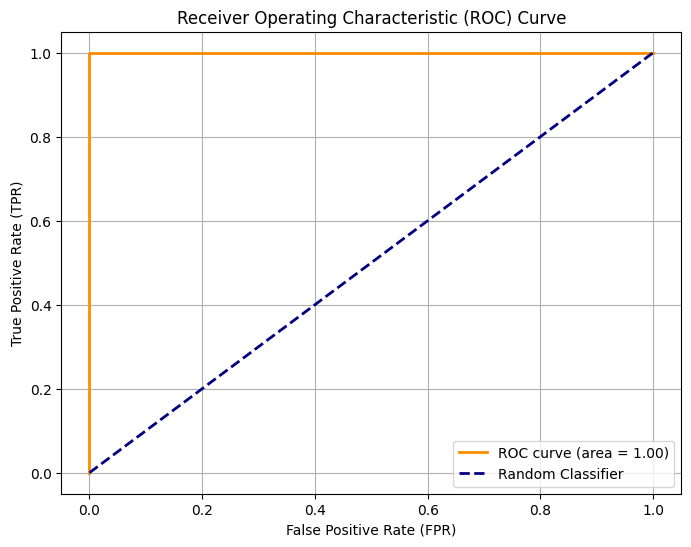

In [ ]:
# Calculate ROC Curve
y_pred_proba = model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The ROC curve illustrates the diagnostic ability of a binary classifier as its discrimination threshold is varied. The Area Under the Curve (AUC) provides an aggregate measure of performance across all possible classification thresholds. An AUC of 1.0 indicates a perfect classifier, while an AUC of 0.5 suggests a random classifier.